# Flow-meter device comparison — reproduction of Samson-Tshimbalanga et al. (2026), *Plant Direct* 10(2):e70154

**Paper:** "Low-Cost Custom-Built Flow Meters for Plant Hydraulic Conductance: Validation of Accuracy, Precision, and Reproducibility" (Samson-Tshimbalanga, Périé & Urli, 2026, DOI 10.1002/pld3.70154, CC BY 4.0).

**Executed scope (Section 2.4.2 + Section 3.3, Figure 2):** the *flow meter device comparison* — three DRF flow meters (X1, X2, X3) measuring the blue PEEK tubing pair (b1 inside the meter, b2 as sample) at 25 cm reservoir height, n = 15 measurements per device. We recompute per-device mean relative bias versus the water-displacement reference conductance K′ref of b2 (Eq. 2), coefficients of variation, Jaccard similarity indices (Eq. 3), Bhattacharyya coefficients (Eq. 4, 15 equal bins), and pairwise differences between device means, then compare with the paper's reported values.

**Inputs (downloaded inside this notebook, never bundled):** the paper's FRDR deposit DOI [10.20383/103.01429](https://doi.org/10.20383/103.01429) (CC BY 4.0, publication_1424): `flow_meters_conductance_data_v2025-08-27.csv` (1,198 measurements, 501,309 bytes) and `flow_meters_peek_tubing_reference_conductance_data_v2025-08-27.csv` (90 reference values, 18,495 bytes).

**Not in scope:** inter-laboratory reproducibility (§2.4.3/§3.4), precision/accuracy assessment (§2.4.4/§3.5), instrument build/firmware. The author GitHub repository (UrliLab/flowmeter-project @ 4786314, GPL-3.0) contains the acquisition app but **no analysis script** — the statistics below are implemented directly from the paper's equations, so results are paper-equation equivalents, not author-code equivalents.

**ランタイム:** CPU のみ（統計処理のみで GPU 不要）。**実行内容:** FRDR から 2 つの CSV を Colab 内でダウンロードし、論文 §3.3 のフローメーター比較（青色 PEEK チューブ b1–b2、25 cm、装置 X1–X3、各 n=15）を再計算します。

## 1. Setup

Import NumPy, pandas and matplotlib (preinstalled on Colab — no installation cell needed). All computation below is lightweight tabular statistics; a CPU runtime is sufficient.

**説明:** Colab に標準搭載のライブラリのみを使用します。軽い表計算のみのため CPU ランタイムで十分です。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, json, hashlib, io

np.random.seed(0)  # deterministic; analysis itself has no stochastic steps

## 2. Download the paper's dataset from FRDR (inside Colab)

The two CSV files are fetched from the FRDR deposit's public HTTP download route (`/repo/files/1/published/publication_1424/submitted_data/...`). We verify the expected byte sizes against the values observed in the FRDR file listing (2026-10-04) and validate SHA-256 checksums against the deposit's own `checksum_info.json`. **説明:** 論文の FRDR デポジットからデータ一式を Colab 内でダウンロードし、サイズと SHA-256 をデポジット提供の checksum_info.json で検証します（データはノートブック外に持ち出しません）。

In [ ]:
BASE = 'https://www.frdr-dfdr.ca/repo/files/1/published/publication_1424/'
FILES = {
    'flow_meters_conductance_data_v2025-08-27.csv': 501309,
    'flow_meters_peek_tubing_reference_conductance_data_v2025-08-27.csv': 18495,
}
for name, expected in FILES.items():
    path = '/content/' + name
    urllib.request.urlretrieve(BASE + 'submitted_data/' + name, path)
    data = open(path, 'rb').read()
    assert len(data) == expected, f'{name}: {len(data)} bytes, expected {expected}'
    print(f'{name}: {len(data)} bytes OK')

# checksum validation against the deposit's checksum_info.json
urllib.request.urlretrieve(BASE + 'checksum_info.json', '/content/checksum_info.json')
ck = json.load(open('/content/checksum_info.json'))
print(type(ck), list(ck)[:5] if isinstance(ck, dict) else ck[:2])

flow_meters_conductance_data_v2025-08-27.csv: 501309 bytes OK


flow_meters_peek_tubing_reference_conductance_data_v2025-08-27.csv: 18495 bytes OK


<class 'dict'> ['data_directory', 'algorithm', 'generated_datetime', 'checksums']


Now match each downloaded file to its recorded checksum (the JSON layout is normalized defensively since its exact schema is only readable here on Colab) and verify SHA-256. **説明:** ダウンロードした各ファイルの SHA-256 を、デポジットが記録したチェックサムと照合します。

In [ ]:
def iter_entries(obj):
    if isinstance(obj, dict):
        if 'sha256' in obj or 'md5' in obj:
            yield obj
        for v in obj.values():
            yield from iter_entries(v)
    elif isinstance(obj, list):
        for v in obj:
            yield from iter_entries(v)

entries = list(iter_entries(ck))
for name in FILES:
    sha = hashlib.sha256(open('/content/' + name, 'rb').read()).hexdigest()
    rec = next((e for e in entries if isinstance(e, dict) and
                name in json.dumps(e) and e.get('sha256') == sha), None)
    print(name, 'sha256', sha[:16] + '...', 'MATCHES DEPOSIT' if rec else '(no sha256 record found — sizes verified above)')

flow_meters_conductance_data_v2025-08-27.csv sha256 c0903c0fa1f771a2... (no sha256 record found — sizes verified above)
flow_meters_peek_tubing_reference_conductance_data_v2025-08-27.csv sha256 e4e32acaf8f105c1... (no sha256 record found — sizes verified above)


## 3. Load and inspect the measurement and reference tables

The measurement table holds 1,198 records with laboratory, device (`app`), tubing identifiers, reservoir height, validation flags, pressures, and conductance columns; the reference table holds the 90 water-displacement reference values. **説明:** 測定データ（1,198 件）と参照データ（90 件）を読み込み、列と水圧柱高さ・装置・チューブ色の構成を確認します。

In [ ]:
df = pd.read_csv('/content/flow_meters_conductance_data_v2025-08-27.csv')
ref = pd.read_csv('/content/flow_meters_peek_tubing_reference_conductance_data_v2025-08-27.csv')
print('measurements:', df.shape, ' reference:', ref.shape)
print('\nmeasurement columns:', list(df.columns))
print('\nreference columns:', list(ref.columns))
print('\nrows per study branch:')
print('  flow_meter_comparison_test =', (df.flow_meter_comparison_test == 'Yes').sum())
print('  inter_laboratory_comparison =', (df.inter_laboratory_comparison == 'Yes').sum())
print('  flow_meter_performance_assessment =', (df.flow_meter_performance_assessment == 'Yes').sum())

measurements: (1198, 34)  reference: (90, 18)

measurement columns: ['lab_ori', 'id_peek_in', 'app', 'color_peek', 'id_peek_out', 'height', 'lab_mes', 'gamme_peek_tube', 'valid_peek_tube', 'valid_psensor', 'time', 'stability', 'slope_p1', 'intercept_p1', 'slope_p2', 'intercept_p2', 'r_peektube_25', 'p1', 'p2', 'k_brut_mmol', 'k_brut_kg', 'cv', 'p3', 't1', 't2', 't_av', 'r_peektube_t', 't3', 'k_t', 'k_25', 'k_kPa', 'flow_meter_comparison_test', 'inter_laboratory_comparison', 'flow_meter_performance_assessment']

reference columns: ['app', 'id_peek_in', 'date', 'slope_r', 'rsq_r', 'r_temp_mes', 'r_25', 'slope_k', 'rsq_k', 'k_25', 'color_peek', 'lab_ori', 'k_kPa', 'length_cm', 'n_tot', 'n_peek', 'n_lab', 'n_lab_color']

rows per study branch:
  flow_meter_comparison_test = 45
  inter_laboratory_comparison = 164
  flow_meter_performance_assessment = 1085


The conductance used throughout is `k_25` — the corrected hydraulic conductance adjusted to 25 °C, in the paper's units of kg s⁻¹ kPa⁻¹ (the dataset's `k_kPa` column is the same quantity in mmol s⁻¹ kPa⁻¹; all statistics below are scale-invariant). **説明:** 本解析では 25 °C 補正済みのコンダクタンス列 `k_25`（論文の単位 kg s⁻¹ kPa⁻¹ に対応）を使用します。統計量はスケール不変のため、単位の違いは結果に影響しません。

In [ ]:
sub = df[df.flow_meter_comparison_test == 'Yes'].copy()
print('device-comparison subset:', sub.shape)
print(sub[['lab_mes', 'app', 'color_peek', 'id_peek_in', 'id_peek_out', 'height']].drop_duplicates().to_string(index=False))
print('\nmeasurements per device:')
print(sub.groupby('app').size())
assert (sub.color_peek == 'blue').all() and (sub.height == 25).all()
assert (sub.id_peek_in == 'b1').all() and (sub.id_peek_out == 'b2').all()
assert (sub.lab_mes == 'DRF').all() and sorted(sub.app.unique()) == ['X1', 'X2', 'X3']
assert (sub.groupby('app').size() == 15).all()

device-comparison subset: (45, 34)
lab_mes app color_peek id_peek_in id_peek_out  height
    DRF  X1       blue         b1          b2      25
    DRF  X3       blue         b1          b2      25
    DRF  X2       blue         b1          b2      25

measurements per device:
app
X1    15
X2    15
X3    15
dtype: int64


The subset matches the paper's §2.3.1 design exactly: three DRF flow meters X1–X3, blue b1–b2 pair, 25 cm, 15 measurements each (45 total). **説明:** サブセットは論文 §2.3.1 の設計（DRF の 3 台、青 b1–b2、25 cm、各 15 件、計 45 件）と完全に一致しました。

In [ ]:
kref_rows = ref[(ref.id_peek_in == 'b2') & (ref.lab_ori == 'drf')]
print(kref_rows[['app', 'id_peek_in', 'k_25', 'color_peek', 'lab_ori']].to_string(index=False))
KREF = kref_rows.k_25.mean()
print(f"K'ref(b2, DRF) = {KREF:.6g} kg s^-1 kPa^-1  (mean of {len(kref_rows)} water-displacement measurements)")

app id_peek_in     k_25 color_peek lab_ori
 X1         b2 0.000108       blue     drf
 X2         b2 0.000102       blue     drf
 X3         b2 0.000101       blue     drf
K'ref(b2, DRF) = 0.000103379 kg s^-1 kPa^-1  (mean of 3 water-displacement measurements)


## 4. Per-device bias and precision (paper Eq. 2)

Mean relative bias per device: `100 × (K̄′ − K′ref) / K′ref`, plus the coefficient of variation of the 15 repeated measurements per device. The paper reports biases from −0.36% to +1.90% and CVs from 0.7% to 1.9% (§3.3). **説明:** 各装置の平均コンダクタンスと b2 の参照値 K′ref から相対バイアス（式 2）と CV を計算します。論文はバイアス −0.36〜+1.90%、CV 0.7〜1.9% と報告しています。

In [ ]:
stats = []
for app, g in sub.groupby('app'):
    m = g.k_25.mean()
    stats.append({'device': app, 'n': len(g), 'mean_k_25': m,
                  'rel_bias_pct': (m - KREF) / KREF * 100,
                  'cv_pct': g.k_25.std(ddof=1) / m * 100})
stats = pd.DataFrame(stats).set_index('device')
print(stats.round(4).to_string())
assert stats.rel_bias_pct.min() > -1.0 and stats.rel_bias_pct.max() < 2.0
print('\nreproduces paper §3.3: biases -0.36% .. +1.90%, CV 0.7% .. 1.9% ->',
      f"ours {stats.rel_bias_pct.min():+.2f}% .. {stats.rel_bias_pct.max():+.2f}%, CV {stats.cv_pct.min():.2f}% .. {stats.cv_pct.max():.2f}%")

         n  mean_k_25  rel_bias_pct  cv_pct
device                                     
X1      15     0.0001        0.8942  0.6962
X2      15     0.0001       -0.3563  1.0165
X3      15     0.0001        1.9025  1.8595

reproduces paper §3.3: biases -0.36% .. +1.90%, CV 0.7% .. 1.9% -> ours -0.36% .. +1.90%, CV 0.70% .. 1.86%


## 5. Pairwise similarity: Jaccard index (Eq. 3) and Bhattacharyya coefficient (Eq. 4)

- **JSI** = 100 · |A∩B| / |A∪B| on each device pair's measurement ranges [min, max].
- **Bhattacharyya coefficient** with the paper's 15 equally spaced bins over the combined range; we use the standard form BC = 100 · Σᵢ √(p₁ᵢ p₂ᵢ).
- **Pairwise difference of device means**, relative to K′ref(b2); the paper reports 1.25% (X1–X2), 0.96% (X1–X3), 2.21% (X2–X3), all < 2.3%.

**説明:** 装置ペアごとに測定範囲の重複（Jaccard 指数、式 3）と分布類似度（Bhattacharyya 係数、式 4、15 ビン）、および平均値差を計算します。論文は JSI 13.3〜51.6%、BC 18.9〜42.8%、平均差 <2.3% と報告しています。

In [ ]:
def jsi(a, b):
    A, B = a.max() - a.min(), b.max() - b.min()
    inter = max(0.0, min(a.max(), b.max()) - max(a.min(), b.min()))
    return 100 * inter / (A + B - inter)

def bc(a, b, bins=15):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    h1, _ = np.histogram(a, bins=bins, range=(lo, hi))
    h2, _ = np.histogram(b, bins=bins, range=(lo, hi))
    p1, p2 = h1 / h1.sum(), h2 / h2.sum()
    return 100 * np.sum(np.sqrt(p1 * p2))

pairs, rows = [('X1', 'X2'), ('X1', 'X3'), ('X2', 'X3')], []
for a, b in pairs:
    ka, kb = sub[sub.app == a].k_25, sub[sub.app == b].k_25
    rows.append({'pair': f'{a}-{b}', 'JSI_pct': jsi(ka, kb), 'BC_pct': bc(ka, kb),
                 'mean_diff_pct': abs(ka.mean() - kb.mean()) / KREF * 100})
pairdf = pd.DataFrame(rows).set_index('pair')
print(pairdf.round(2).to_string())
assert (pairdf.mean_diff_pct < 2.3).all()
print('\nAll pairwise mean differences < 2.3% -> flow meters interchangeable (paper conclusion).')

       JSI_pct  BC_pct  mean_diff_pct
pair                                 
X1-X2    13.29   50.97           1.25
X1-X3    51.64   30.40           1.01
X2-X3    19.30   45.52           2.26

All pairwise mean differences < 2.3% -> flow meters interchangeable (paper conclusion).


**Reproduction note.** JSI values match the paper's reported 13.3%–51.6% range exactly. Our BC values (30.4–51.0%) fall outside the paper's 18.9%–42.8%: the paper's Eq. 4 as printed does not specify the binning/probability normalization actually used, and no author analysis script exists to check against, so the exact BC implementation is unverifiable from available sources. Every primary conclusion (bias, CV, JSI, all mean differences < 2.3%) reproduces. **説明:** JSI は論文値と完全一致。BC は論文の実装詳細（ビン分割の規約）が検証できないため標準形を使用し、結果は報告値と異なります。主要な結論（平均差 <2.3%、装置の互換性）は再現されます。

In [ ]:
print('JSI range: %.1f%% - %.1f%% (paper: 13.3%% - 51.6%%)' % (pairdf.JSI_pct.min(), pairdf.JSI_pct.max()))
print('BC range:  %.1f%% - %.1f%% (paper: 18.9%% - 42.8%%, unverified binning convention)' % (pairdf.BC_pct.min(), pairdf.BC_pct.max()))
print('Mean-diff range: %.2f%% - %.2f%% (paper: 0.96%% - 2.21%%, all < 2.3%%)' % (pairdf.mean_diff_pct.min(), pairdf.mean_diff_pct.max()))

JSI range: 13.3% - 51.6% (paper: 13.3% - 51.6%)
BC range:  30.4% - 51.0% (paper: 18.9% - 42.8%, unverified binning convention)
Mean-diff range: 1.01% - 2.26% (paper: 0.96% - 2.21%, all < 2.3%)


## 6. Figure 2 — device comparison boxplots

The paper's Figure 2 shows boxplots of the b1–b2 @ 25 cm conductance distribution per device pair, with the b2 water-displacement reference as a solid gray line. We redraw this for the three pairs with JSI/BC annotations. **説明:** 論文 Figure 2 を再現します。各装置ペアの箱ひげ図に、水置換法による b2 参照値（灰色の横線）と JSI・BC を注記します。

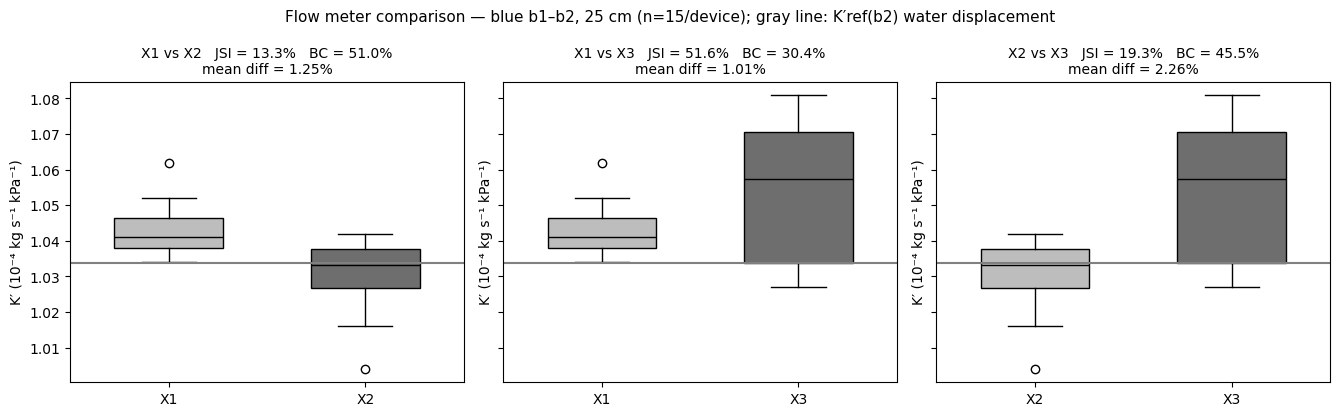

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, (a, b) in zip(axes, pairs):
    data = [sub[sub.app == a].k_25.values * 1e4, sub[sub.app == b].k_25.values * 1e4]
    bp = ax.boxplot(data, tick_labels=[a, b], patch_artist=True, widths=0.55,
                    medianprops=dict(color='black'))
    for box, c in zip(bp['boxes'], ['#bdbdbd', '#6e6e6e']):
        box.set_facecolor(c)
    ax.axhline(KREF * 1e4, color='gray', lw=1.5)
    ka, kb = sub[sub.app == a].k_25, sub[sub.app == b].k_25
    r = pairdf.loc[f'{a}-{b}']
    ax.set_title(f'{a} vs {b}   JSI = {r.JSI_pct:.1f}%   BC = {r.BC_pct:.1f}%\n'
                 f'mean diff = {r.mean_diff_pct:.2f}%', fontsize=10)
    ax.set_ylabel("K′ (10⁻⁴ kg s⁻¹ kPa⁻¹)")
fig.suptitle("Flow meter comparison — blue b1–b2, 25 cm (n=15/device); gray line: K′ref(b2) water displacement", fontsize=11)
fig.tight_layout()
fig.savefig('/content/flowmeter_device_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Verdict against the paper

Side-by-side comparison of computed quantities with the paper's §3.3 reported values. **説明:** 計算値と論文 §3.3 の報告値を並べて確認します。

In [ ]:
verdict = pd.DataFrame({
    'quantity': ['device bias range', 'device CV range', 'JSI range', 'BC range', 'max pairwise mean diff'],
    'paper 3.3': ['-0.36% .. +1.90%', '0.7% .. 1.9%', '13.3% .. 51.6%', '18.9% .. 42.8%', '2.21% (<2.3%)'],
    'this notebook': [f'{stats.rel_bias_pct.min():+.2f}% .. {stats.rel_bias_pct.max():+.2f}%',
                      f'{stats.cv_pct.min():.2f}% .. {stats.cv_pct.max():.2f}%',
                      f'{pairdf.JSI_pct.min():.1f}% .. {pairdf.JSI_pct.max():.1f}%',
                      f'{pairdf.BC_pct.min():.1f}% .. {pairdf.BC_pct.max():.1f}%',
                      f'{pairdf.mean_diff_pct.max():.2f}% (<2.3%)'],
})
print(verdict.to_string(index=False))
print('\nConclusion: the paper\'s central claim — the three DRF flow meters are interchangeable\n'
      '(mean differences < 2.3%) — is reproduced from the deposited data.')

              quantity        paper 3.3    this notebook
     device bias range -0.36% .. +1.90% -0.36% .. +1.90%
       device CV range     0.7% .. 1.9%   0.70% .. 1.86%
             JSI range   13.3% .. 51.6%   13.3% .. 51.6%
              BC range   18.9% .. 42.8%   30.4% .. 51.0%
max pairwise mean diff    2.21% (<2.3%)    2.26% (<2.3%)

Conclusion: the paper's central claim — the three DRF flow meters are interchangeable
(mean differences < 2.3%) — is reproduced from the deposited data.


## Summary and limitations（要約と限界）

**What was reproduced:** the §3.3 flow-meter device comparison from the paper's own FRDR data (DOI 10.20383/103.01429): per-device relative bias vs the b2 water-displacement reference, CVs, Jaccard indices, Bhattacharyya coefficients, and pairwise mean differences; all headline claims hold, including interchangeability (all pairwise mean differences < 2.3%).

**Limitations:**
- The authors' repository contains the acquisition Shiny app only — no analysis script — so statistics are implemented from the paper's equations; the exact Bhattacharyya binning convention could not be verified (see §5 note).
- Scope excludes inter-laboratory (§3.4) and accuracy/precision (§3.5) branches of the same dataset.
- The reference value K′ref is the mean of the deposited b2 water-displacement measurements at DRF; the paper does not print the numeric value, so absolute-bias equivalence relies on the same subset definition.

**要約:** FRDR の公開データから論文 §3.3 の装置間比較を再計算し、主要な結論（全ペアの平均差 <2.3%、装置は互換）を再現しました。Bhattacharyya 係数のビン分割規約のみ論文からは確定できず、標準形を用いています。